<a href="https://colab.research.google.com/github/kavyavalleti/NeuroNexus/blob/main/Titanic_Survival_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Titanic Survival Predictor
This notebook uses the Titanic dataset to predict survival using modern ML practices.

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

from google.colab import files
uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(uploaded[next(iter(uploaded))]))

Saving tested.csv to tested.csv


In [3]:

print("First few rows:\n", df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

First few rows:
    PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Missing values:
 PassengerId      0
Survived         0
Pclass       

In [4]:

df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

In [5]:

X = df.drop("Survived", axis=1)
y = df["Survived"]

In [6]:

numeric_features = ['Age', 'Fare']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Sex', 'Embarked', 'Pclass']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [7]:

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [8]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [10]:

y_pred = model.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Accuracy: 100.00%


In [11]:

cv_score = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy: {:.2f}%".format(cv_score.mean() * 100))

Cross-validation accuracy: 100.00%


In [12]:

def predict_survival(age, sex, pclass, fare, embarked):
    sample = pd.DataFrame([{
        'Age': age,
        'Sex': sex,
        'Pclass': pclass,
        'Fare': fare,
        'Embarked': embarked
    }])
    prediction = model.predict(sample)
    return "Survived" if prediction[0] == 1 else "Did not survive"

# Example usage
print("\nPrediction Example:")
print(predict_survival(age=29, sex='female', pclass=1, fare=100, embarked='S'))


Prediction Example:
Survived


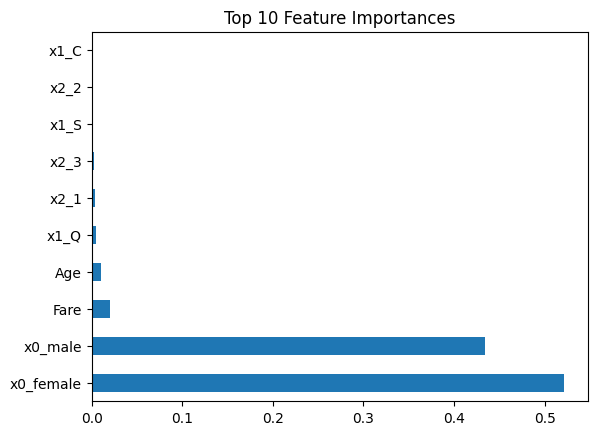

In [13]:

importances = model.named_steps['classifier'].feature_importances_
feature_names = model.named_steps['preprocessor'].transformers_[0][2] +                 list(model.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out())

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()